In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)

import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

import calendar

## ANALISIS DEL CSV

In [2]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

In [3]:
# Show data
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df_hotel.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [4]:
df_hotel.shape


(119390, 32)

In [5]:
#df_hotel.head(20).T
df_hotel.tail(10).T

,119380,119381,119382,119383,119384,119385,119386,119387,119388,119389
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0
lead_time,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,3,3,4,4,5,5,5,5,5,7
adults,2,2,3,2,2,2,3,2,2,2


In [38]:
# df_hotel.describe(include="number").T
df_hotel['customer_type'].describe().T

count        119390
unique            4
top       Transient
freq          89613
Name: customer_type, dtype: object

In [40]:
df_hotel['customer_type'].isna().sum()

0

In [23]:
print(f"Country number: {df_hotel['country'].value_counts(normalize=True)}")
print(f"Null countries: {df_hotel['country'].isna().sum()}")
print(f"Meal number: {df_hotel['meal'].value_counts(normalize=True)}")

Country number: country
PRT    0.408656
GBR    0.102008
FRA    0.087593
ESP    0.072059
DEU    0.061286
         ...   
DJI    0.000008
BWA    0.000008
HND    0.000008
VGB    0.000008
NAM    0.000008
Name: proportion, Length: 177, dtype: float64
Null countries: 488
Meal number: meal
BB           0.773180
HB           0.121141
SC           0.089203
Undefined    0.009791
FB           0.006684
Name: proportion, dtype: float64


In [8]:
precio_negativo = df_hotel[df_hotel['adr'] < 0]
precio_negativo.T

,14969
hotel,Resort Hotel
is_canceled,0
lead_time,195
arrival_date_year,2017
arrival_date_month,March
arrival_date_week_number,10
arrival_date_day_of_month,5
stays_in_weekend_nights,4
stays_in_week_nights,6
adults,2


In [9]:
df_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [ ]:

num_df = df_hotel.select_dtypes(include=['number'])
numeric_columns = num_df.columns
print(f"Numeric columns: {numeric_columns}")
object_df = df_hotel.select_dtypes(include=['object'])
object_columns = object_df.columns
print(f"Object / Categorical columns: {object_columns}")

print(f"{df_hotel.isnull().sum()}")
df_hotel[df_hotel.duplicated(keep=False)]
cols_con_negativos = num_df.columns[(num_df < 0).any()].tolist()
print(f"Cols with negative values: {cols_con_negativos}")


Numeric columns: Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Object / Categorical columns: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival

In [11]:
print(f"Number of categories by column:\n{df_hotel.select_dtypes(include='object').nunique().sort_values(ascending=False)}")
print("")
for i in range(len(object_columns)):
    if (df_hotel[object_columns[i]] == 'Undefined').sum() > 0:
        print(f"Count of {object_columns[i]} 'undefined' : {(df_hotel[object_columns[i]] == 'Undefined').sum()}")

Number of categories by column:
reservation_status_date    926
country                    177
arrival_date_month          12
assigned_room_type          12
reserved_room_type          10
market_segment               8
meal                         5
distribution_channel         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64



In [11]:
df_hotel.duplicated().sum()

31994

In [12]:
df_hotel.shape

(119390, 32)

In [41]:
df_hotel.drop(columns=['repeat_count'], inplace=True)
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [42]:
# Opción más simple y legible
df_hotel['repeat_count'] = df_hotel.groupby(
    df_hotel.columns.tolist(), 
    dropna=False  # incluye filas con NaN en el groupby
).transform('size')

df_hotel.head(20)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,repeat_count
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03,1
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,303.0,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03,1
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,240.0,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06,1
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,15.0,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22,1


In [ ]:
mayor_repes = df_hotel[df_hotel['repeat_count'] < df_hotel['repeat_count'].max()]
df_hotel[df_hotel['repeat_count'] > 1].value_counts(normalize=True)

hotel         is_canceled  lead_time  arrival_date_year  arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies  meal  country  market_segment  distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  reserved_room_type  assigned_room_type  booking_changes  deposit_type  agent  company  days_in_waiting_list  customer_type    adr     required_car_parking_spaces  total_of_special_requests  reservation_status  reservation_status_date  repeat_count
City Hotel    0            256        2016               October             43                        16                         2                        3                     2       0.0       0       BB    DEU      Online TA       TA/TO                 0                  0                       0                               A                   A                   0                No Deposit    9.0    333.0    0  

In [62]:
print(f"Filas totales: {len(df_hotel)}")
print(f"Filas duplicadas exactas: {df_hotel.duplicated().sum()}")
print(f"Porcentaje: {df_hotel.duplicated().mean():.2%}")

Filas totales: 119390
Filas duplicadas exactas: 31994
Porcentaje: 26.80%


## EDA

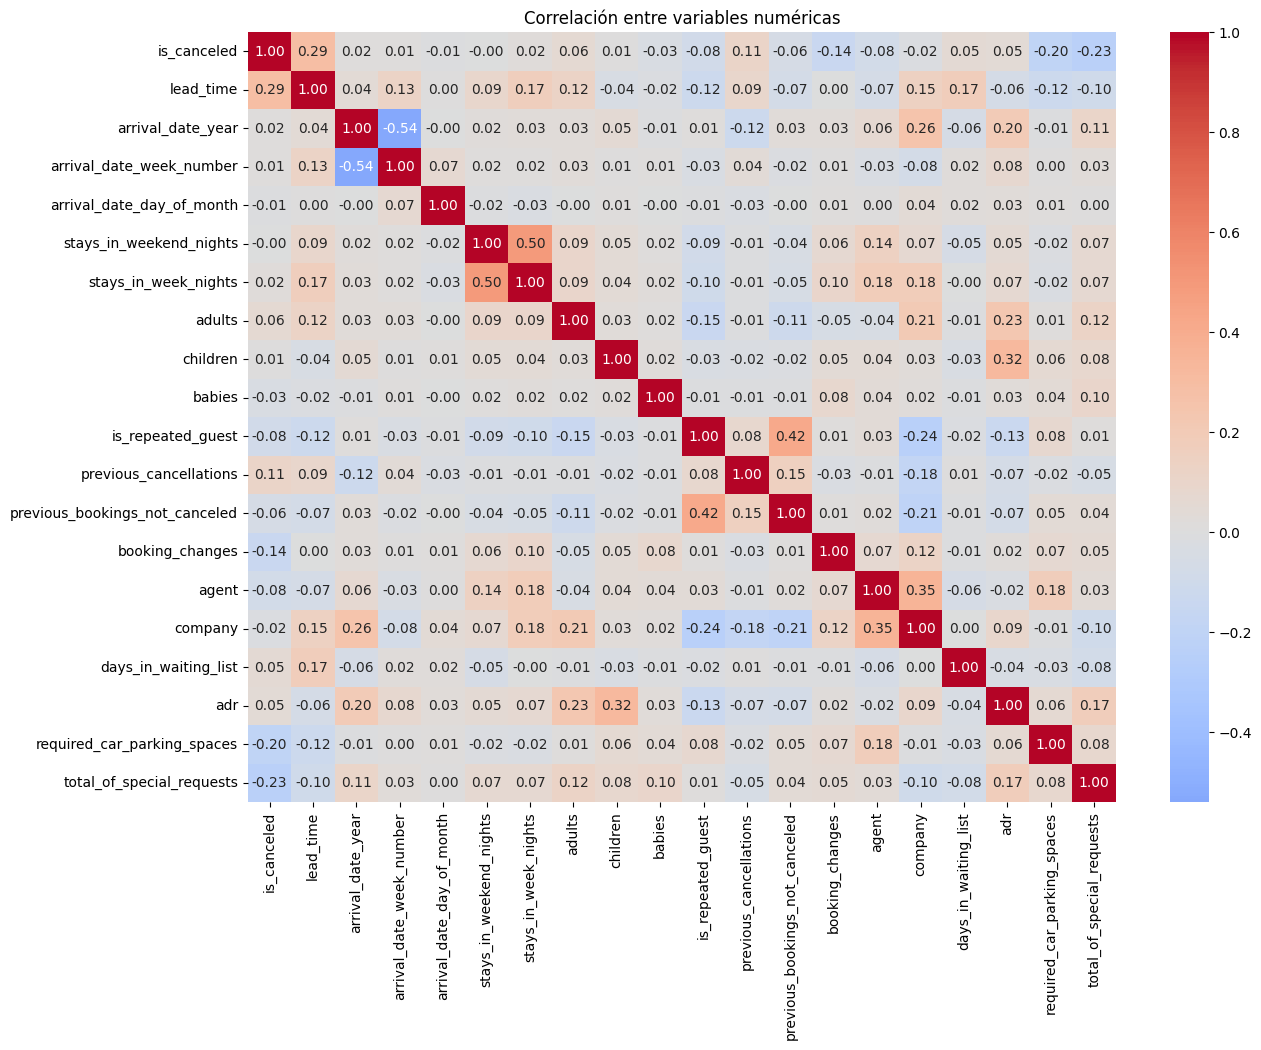

In [4]:
num_cols = df_hotel.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_hotel[num_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('Correlación entre variables numéricas')
plt.show()

In [27]:
print(f"Paises total: {len(df_hotel['country'].unique())}")

frecuencias = df_hotel['country'].value_counts(normalize=True)
print(f"Paises con frecuencia <= 1%: {len(frecuencias[frecuencias <= 0.01].index.tolist())}")
print(f"Paises con frecuencia entre 1% y 5%: {len(frecuencias[frecuencias.between(0.01, 0.051)].index.tolist())}")
print(f"Paises con frecuencia entre 5% y 10%: {len(frecuencias[frecuencias.between(0.05, 0.1)].index.tolist())}")

Paises total: 178
Paises con frecuencia <= 1%: 163
Paises con frecuencia entre 1% y 5%: 9
Paises con frecuencia entre 5% y 10%: 3
